# Parameters

In [1]:
import sys
import os
from pathlib import Path
import pandas as pd

# ===== CONFIGURAÇÃO DE CAMINHOS =====
current_notebook = Path.cwd()  
project_root = current_notebook.parent.parent 

# Adiciona o diretório raiz ao sys.path
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Adiciona o diretório Modules ao sys.path
modules_dir = project_root / "Modules"
if str(modules_dir) not in sys.path:
    sys.path.insert(0, str(modules_dir))

# ===== IMPORTS DOS MÓDULOS =====
import Modules.ClusterGmmModule as cluster
import Modules.FutureAnalysisModule as fa
from Modules.config import CONFIG

# ===== CONFIGURAÇÕES DO PROJETO =====
DATAPATH = CONFIG["datapath"]
COVID_TRAIN_DATA_FILE = CONFIG["covid_train_data_file"]
COVID_TEST_DATA_FILE = CONFIG["covid_test_data_file"]
FUTURE_DATA_FILE = CONFIG["future_data_file"]

CONTROL_GROUP_TRAIN = CONFIG["control_group_train"]
CONTROL_GROUP_TEST = CONFIG["control_group_test"]
CONTROL_GROUP_READMISSION = CONFIG["control_group_readmission"]

FIGSIZE_CLUSTER_HEATMAP = CONFIG["figsize_cluster_heatmap"]
FIGSIZE_FUTURE_HEATMAP = CONFIG["figsize_future_heatmap"]
IMAGES_SAVE_PATH = CONFIG["image_save_path"]
TRIALS_OPTUNA = 80

# Import data

In [2]:
# ===== CARREGAMENTO DOS DADOS =====
data_folder = current_notebook / DATAPATH

covid_train = pd.read_csv(data_folder / COVID_TRAIN_DATA_FILE)
covid_test = pd.read_csv(data_folder / COVID_TEST_DATA_FILE)
future_data = pd.read_csv(data_folder / FUTURE_DATA_FILE)

control_train = pd.read_csv(data_folder / CONTROL_GROUP_TRAIN)
control_test = pd.read_csv(data_folder / CONTROL_GROUP_TEST)
control = pd.concat([control_train, control_test], axis=0)
control_readmission = pd.read_csv(data_folder / CONTROL_GROUP_READMISSION)

# Feature engineering: morte após a internação
covid_train['died_after'] = ((covid_train['died'] == 1) & (covid_train['died_in_stay'] == 0)).astype(int)
covid_test['died_after'] = ((covid_test['died'] == 1) & (covid_test['died_in_stay'] == 0)).astype(int)
future_data['died_after'] = ((future_data['died'] == 1) & (future_data['died_in_stay'] == 0)).astype(int)

In [3]:
data_covid = pd.concat([covid_train, covid_test], axis=0)
data_covid = data_covid.sample(frac=1, random_state=42).reset_index(drop=True)

# Mice Data

In [4]:
categorical_features = [
            "myocardial_infarct",
            "congestive_heart_failure",
            "peripheral_vascular_disease",
            "cerebrovascular_disease",
            "dementia",
            "chronic_pulmonary_disease",
            "rheumatic_disease",
            "peptic_ulcer_disease",
            "mild_liver_disease",
            "diabetes_without_cc",
            "diabetes_with_cc",
            "paraplegia",
            "renal_disease",
            "malignant_cancer",
            "severe_liver_disease",
            "metastatic_solid_tumor",
            "aids",
            "gender_M",
            "died_in_stay",
            "died_after",
            "died",
            "COVID"
        ]

In [5]:
features_not_considered = ['died', 'died_in_stay', 'died_after', 'COVID', 'subject_id', 'hadm_id']

In [6]:
helper = cluster.GmmClusterHelper(data=data_covid, features_not_considered=features_not_considered)

2026-02-19 18:57:17,312 - ClusterBaseModule - INFO - ClusterBaseHelper initialized: 3355 records, 67 features (22 categorical, 51 numerical)
2026-02-19 18:57:17,313 - Modules.ClusterGmmModule - INFO - GmmClusterHelper initialized: 3355 records, scaler='standard'


## Find best hyperparameters for DBSCAN - cluster_selection_method: 'eom'

In [7]:
param = {
    "n_components": {"min": 2, "max": 15},
    "covariance_type": ["full", "tied", "diag", "spherical"]
}

### DBCV

In [ ]:
os.environ["PYTHONWARNINGS"] = "ignore"
dbcv_df, dbcv_param, dbcv_best = helper.optuna_grid_search(
    parameters=param, 
    n_trials=TRIALS_OPTUNA, 
    saveStorage=True, 
    metric="dbcv",
)

[I 2026-01-20 18:15:34,392] A new study created in RDB with name: Optuna Study GMM All DBCV 0
[I 2026-01-20 18:15:37,538] Trial 0 finished with value: -0.9419755546306737 and parameters: {'n_components': 4, 'covariance_type': 'spherical'}. Best is trial 0 with value: -0.9419755546306737.
[I 2026-01-20 18:15:40,829] Trial 1 finished with value: -0.9814360791773318 and parameters: {'n_components': 12, 'covariance_type': 'tied'}. Best is trial 0 with value: -0.9419755546306737.
[I 2026-01-20 18:15:44,066] Trial 2 finished with value: -0.9965277466652814 and parameters: {'n_components': 3, 'covariance_type': 'tied'}. Best is trial 0 with value: -0.9419755546306737.
[I 2026-01-20 18:15:48,673] Trial 3 finished with value: -0.9249375642558062 and parameters: {'n_components': 9, 'covariance_type': 'full'}. Best is trial 3 with value: -0.9249375642558062.
[I 2026-01-20 18:15:52,295] Trial 4 finished with value: -0.9465577545473152 and parameters: {'n_components': 6, 'covariance_type': 'diag'}.


Best parameters: {'n_components': 11, 'covariance_type': 'diag'}
Best DBCV score: -0.7724433146245168



### DISCO

In [ ]:
os.environ['PYTHONWARNINGS'] = 'ignore'
disco_df, disco_param, disco_best = helper.optuna_grid_search(
    parameters=param, 
    n_trials=TRIALS_OPTUNA, 
    saveStorage=True, 
    metric="disco",
)

[I 2026-01-20 18:19:59,235] A new study created in RDB with name: Optuna Study GMM All DISCO 0
[I 2026-01-20 18:19:59,930] Trial 0 finished with value: 0.017298185671088713 and parameters: {'n_components': 3, 'covariance_type': 'spherical'}. Best is trial 0 with value: 0.017298185671088713.
[I 2026-01-20 18:20:00,674] Trial 1 finished with value: -0.1178606336230372 and parameters: {'n_components': 3, 'covariance_type': 'tied'}. Best is trial 0 with value: 0.017298185671088713.
[I 2026-01-20 18:20:01,501] Trial 2 finished with value: -0.13178588448059242 and parameters: {'n_components': 14, 'covariance_type': 'tied'}. Best is trial 0 with value: 0.017298185671088713.
[I 2026-01-20 18:20:02,213] Trial 3 finished with value: -0.16996309268170012 and parameters: {'n_components': 6, 'covariance_type': 'diag'}. Best is trial 0 with value: 0.017298185671088713.
[I 2026-01-20 18:20:04,830] Trial 4 finished with value: -0.16220418245666163 and parameters: {'n_components': 10, 'covariance_type'


Best parameters: {'n_components': 3, 'covariance_type': 'diag'}
Best DISCO score: 0.15398093919379258



### DSI

In [ ]:
os.environ['PYTHONWARNINGS'] = 'ignore'
dsi_df, dsi_param, dsi_best = helper.optuna_grid_search(
    parameters=param, 
    n_trials=TRIALS_OPTUNA, 
    saveStorage=True, 
    metric="dsi",
)

[I 2026-01-20 18:20:56,171] A new study created in RDB with name: Optuna Study GMM All DSI 0
[I 2026-01-20 18:20:57,558] Trial 0 finished with value: 0.046 and parameters: {'n_components': 6, 'covariance_type': 'tied'}. Best is trial 0 with value: 0.046.
[I 2026-01-20 18:20:57,858] Trial 1 finished with value: -3.0 and parameters: {'n_components': 2, 'covariance_type': 'full'}. Best is trial 0 with value: 0.046.
[I 2026-01-20 18:21:00,399] Trial 2 finished with value: 0.097 and parameters: {'n_components': 6, 'covariance_type': 'full'}. Best is trial 2 with value: 0.097.
[I 2026-01-20 18:21:01,801] Trial 3 finished with value: 0.153 and parameters: {'n_components': 15, 'covariance_type': 'spherical'}. Best is trial 3 with value: 0.153.
[I 2026-01-20 18:21:03,374] Trial 4 finished with value: 0.12 and parameters: {'n_components': 3, 'covariance_type': 'full'}. Best is trial 3 with value: 0.153.
[I 2026-01-20 18:21:05,186] Trial 5 finished with value: 0.1 and parameters: {'n_components':


Best parameters: {'n_components': 8, 'covariance_type': 'full'}
Best DSI score: 0.186



### Silhouette

In [ ]:
os.environ['PYTHONWARNINGS'] = 'ignore'
silhouette_df, silhouette_param, silhouette_best = helper.optuna_grid_search(
    parameters=param, 
    n_trials=TRIALS_OPTUNA, 
    saveStorage=True, 
    metric="silhouette",
)

[I 2026-01-20 18:23:34,092] A new study created in RDB with name: Optuna Study GMM All SILHOUETTE 0
[I 2026-01-20 18:23:34,338] Trial 0 finished with value: -0.19 and parameters: {'n_components': 10, 'covariance_type': 'spherical'}. Best is trial 0 with value: -0.19.
[I 2026-01-20 18:23:34,619] Trial 1 finished with value: -0.201 and parameters: {'n_components': 9, 'covariance_type': 'tied'}. Best is trial 0 with value: -0.19.
[I 2026-01-20 18:23:35,972] Trial 2 finished with value: -0.211 and parameters: {'n_components': 6, 'covariance_type': 'full'}. Best is trial 0 with value: -0.19.
[I 2026-01-20 18:23:36,338] Trial 3 finished with value: -0.188 and parameters: {'n_components': 13, 'covariance_type': 'tied'}. Best is trial 3 with value: -0.188.
[I 2026-01-20 18:23:36,559] Trial 4 finished with value: -0.047 and parameters: {'n_components': 4, 'covariance_type': 'tied'}. Best is trial 4 with value: -0.047.
[I 2026-01-20 18:23:36,798] Trial 5 finished with value: 0.177 and parameters


Best parameters: {'n_components': 2, 'covariance_type': 'spherical'}
Best SILHOUETTE score: 0.34



### Metrics

In [ ]:
helper.clustering(
    n_components=dbcv_param["n_components"],
    covariance_type=dbcv_param["covariance_type"],
)
helper.get_metrics()

{'silhouette': -0.337,
 'dbcv': -0.7724433146245168,
 'dsi': np.float64(0.149),
 'disco': np.float64(-0.20129229058760162)}

In [ ]:
helper.clustering(
    n_components=disco_param["n_components"],
    covariance_type=disco_param["covariance_type"],
)
helper.get_metrics()

{'silhouette': 0.177,
 'dbcv': -0.930288257923437,
 'dsi': np.float64(0.14),
 'disco': np.float64(0.15398093919379258)}

In [ ]:
helper.clustering(
    n_components=dsi_param["n_components"],
    covariance_type=dsi_param["covariance_type"],
)
helper.get_metrics()

{'silhouette': -0.351,
 'dbcv': -0.9598945107893729,
 'dsi': np.float64(0.186),
 'disco': np.float64(-0.140602298899164)}

In [ ]:
helper.clustering(
    n_components=silhouette_param["n_components"],
    covariance_type=silhouette_param["covariance_type"],
)
helper.get_metrics()

{'silhouette': 0.34,
 'dbcv': -0.9932070305903453,
 'dsi': np.float64(0.201),
 'disco': np.float64(0.3792171258822338)}

In [ ]:
log_file = "../log.csv"
current_dir = os.getcwd()
log_file_path = os.path.join(current_dir, log_file)

metrics = helper.get_metrics()

# Add line to save log
if os.path.exists(log_file_path):
    with open(log_file_path, 'a') as f:
        f.write(f"GMM, None, Comprehensive, {metrics['disco']}, {metrics['dbcv']}, {metrics['dsi']}, {metrics['silhouette']}\n")

## Best Result -> DISCO

In [ ]:
best_param = dsi_param

In [8]:
helper.clustering(
    n_components=silhouette_param["n_components"],
    covariance_type=silhouette_param["covariance_type"],
)
helper.get_metrics()

NameError: name 'silhouette_param' is not defined

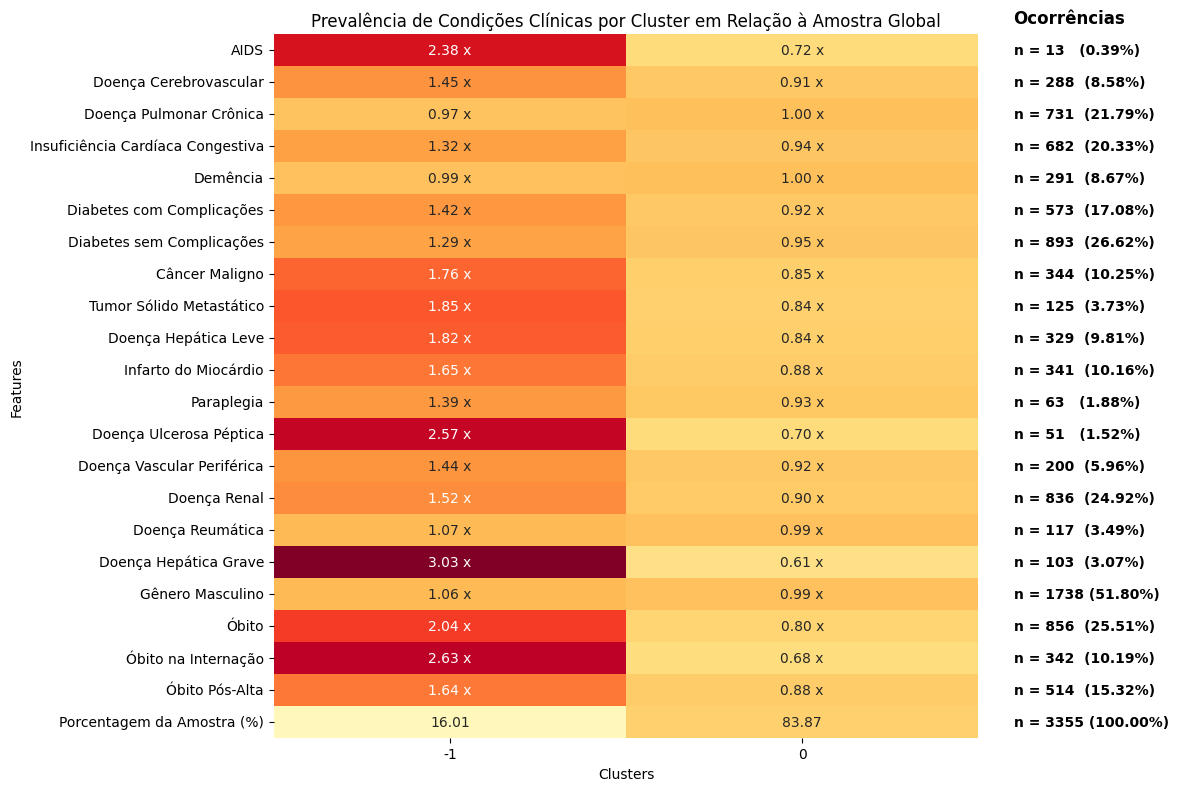

In [ ]:
helper.heatmap_clusters_categorical(
    figsize=FIGSIZE_CLUSTER_HEATMAP,
    relativeTotal=True,
    savepath=IMAGES_SAVE_PATH + "gmm-all-categorical-relative",
)

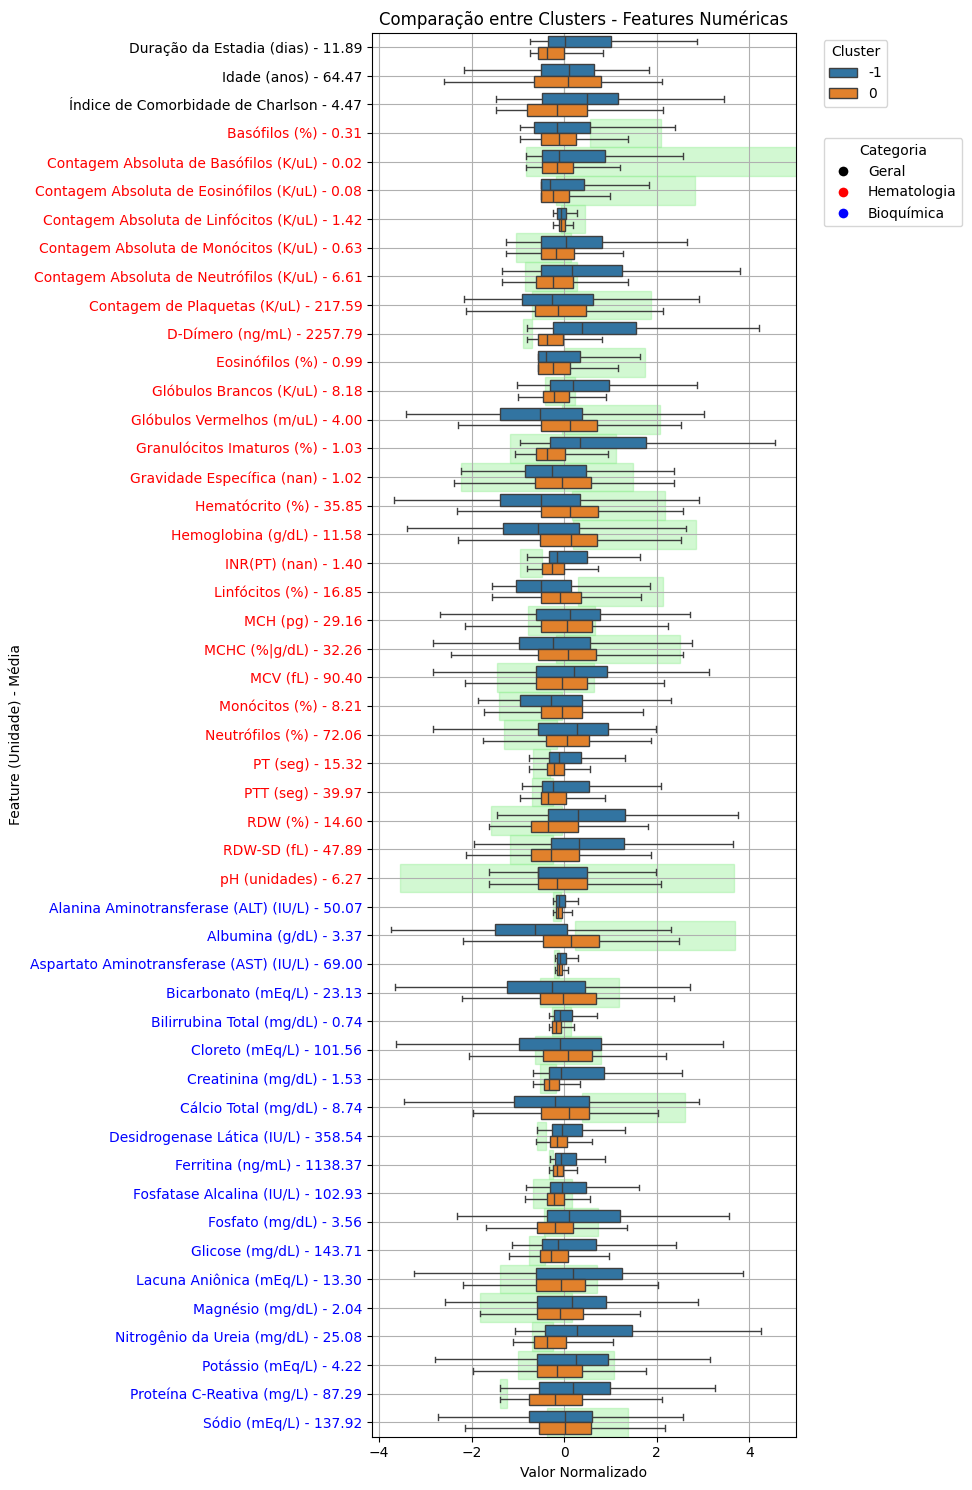

[]

In [ ]:
helper.show_cluster_compare_numerical(
    figsize=(10, 15),
    savepath=IMAGES_SAVE_PATH + "gmm-all-numerical",
)

In [ ]:
selected_clusters = [-1, 0]

In [ ]:
helper.set_clustered_autoencoder()

Autoencoder is not fitted yet, will be pretrained.
Start training with clustering loss.
Epoch: 100%|██████████| 100/100 [00:24<00:00,  4.04it/s]


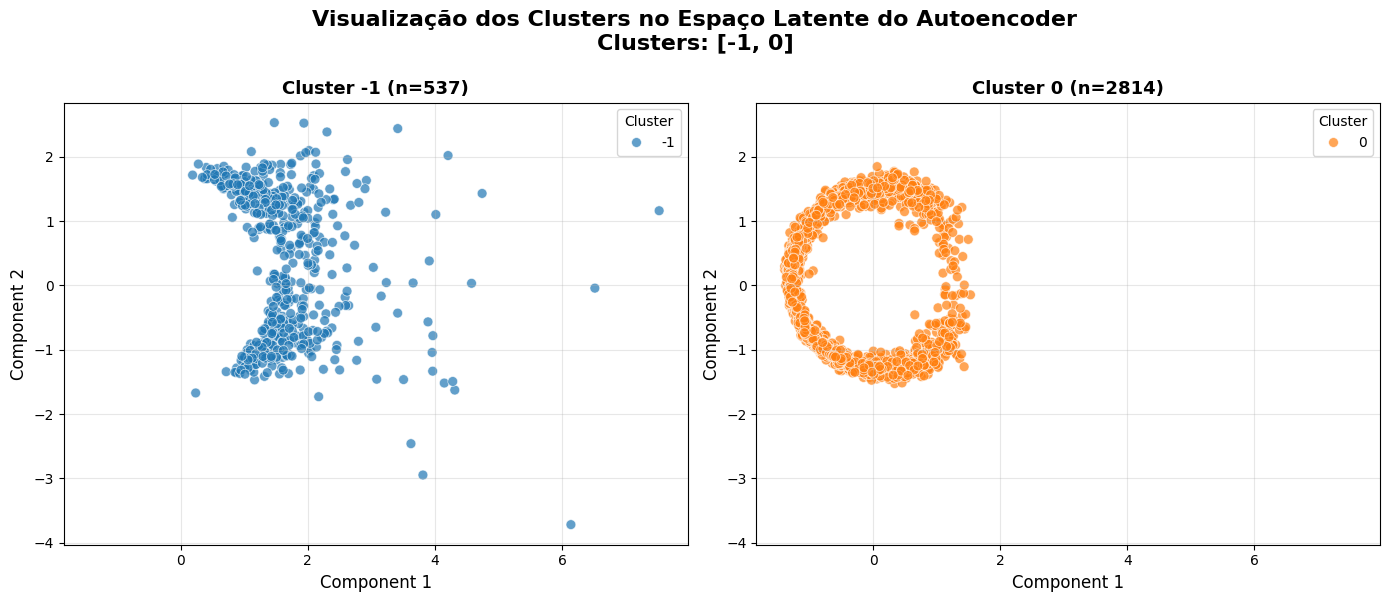

In [ ]:
helper.show_clustered_autoencoder(selected_clusters=selected_clusters, savepath=IMAGES_SAVE_PATH + "gmm-all-autoencoder")

##### Future data


2026-01-20 17:35:32,846 - Modules.FutureAnalysisModule - WARNING - 84 subject_ids in target data are missing from reference data. These will be filtered out.
2026-01-20 17:35:32,856 - Modules.FutureAnalysisModule - WARNING - 1038 subject_ids in target data are missing from reference data. These will be filtered out.
2026-01-20 17:35:32,878 - Modules.FutureAnalysisModule - INFO - Clusters inserted for 6455 records
2026-01-20 17:35:32,888 - Modules.FutureAnalysisModule - INFO - Auto-detected 19 binary features for analysis
2026-01-20 17:35:32,911 - Modules.FutureAnalysisModule - INFO - Delta clusters calculated for 1 clusters
2026-01-20 17:35:32,914 - Modules.FutureAnalysisModule - INFO - FutureAnalysisHelper initialized with 3355 past records and 2257 future records
2026-01-20 17:35:32,919 - Modules.FutureAnalysisModule - INFO - Clusters inserted for 976 records
2026-01-20 17:35:32,923 - Modules.FutureAnalysisModule - INFO - Auto-detected 20 binary features for analysis
2026-01-20 17:35

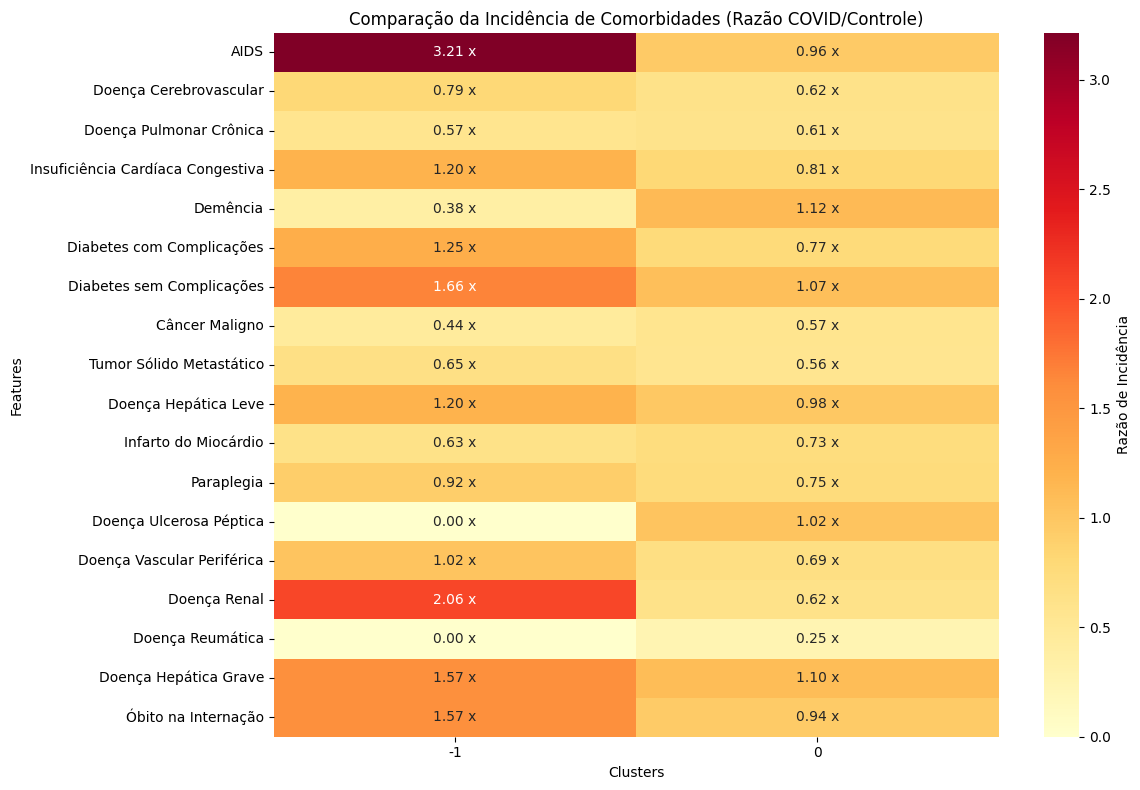

In [ ]:
future_helper = fa.FutureAnalysisHelper(
    helper.clustered_data, future_data, control, control_readmission
)
delta = future_helper.get_delta_clusters(percentage=True, relative_total=True)
future_helper.show_delta_heatmap(
    figsize=FIGSIZE_FUTURE_HEATMAP,
    relative_total=True,
    selected_clusters=selected_clusters,
    savepath=IMAGES_SAVE_PATH + "gmm-all-future",
)

In [ ]:
future_helper.get_mean_readmission()

2026-01-20 17:35:33,322 - Modules.FutureAnalysisModule - INFO - Clusters inserted for 2257 records
2026-01-20 17:35:33,325 - Modules.FutureAnalysisModule - INFO - Calculated mean readmission for 2 clusters


{'Mean readmission Cluster -1': np.float64(2.61),
 'Mean readmission Cluster 0': np.float64(2.26),
 'Overall Mean readmission': 2.31}

In [ ]:
future_helper.get_mean_days_gap()

2026-01-20 17:35:33,339 - Modules.FutureAnalysisModule - INFO - Clusters inserted for 976 records
2026-01-20 17:35:33,341 - Modules.FutureAnalysisModule - INFO - Calculated mean days gap for 2 clusters


{'Mean days gap Cluster -1': np.float64(112.96),
 'Mean days gap Cluster 0': np.float64(130.23),
 'Overall Mean days gap': 127.49}

In [ ]:
future_helper.get_mortality_rates(only_first_admission=True)

2026-01-20 17:35:33,405 - Modules.FutureAnalysisModule - INFO - Clusters inserted for 976 records
2026-01-20 17:35:33,417 - Modules.FutureAnalysisModule - INFO - Calculated mortality rates for 2 clusters


{'Mortality rate Cluster -1': 0.04,
 'Mortality rate Cluster 0': 0.12,
 'Overall Mortality rate': 0.09}

### Add Log

In [ ]:
# log_file = "../log.csv"
# current_dir = os.getcwd()
# log_file_path = os.path.join(current_dir, log_file)

# metrics = helper.getMetrics()

# # Add line to save log
# if os.path.exists(log_file_path):
#     with open(log_file_path, 'a') as f:
#         f.write(f"GMM, None, Comprehensive, {metrics['disco']}, {metrics['dbcv']}, {metrics['dsi']}, {metrics['silhouette']}\n")